# 02 · Forecast tournament & backtesting

**Goal:** a 12-month rolling forecast for all 27 P&L lines that beats the static budget, with an *expected range* for flagging surprises.

**How I test fairly:** I replay the last 24 month-ends. At each one I train only on data available then and score the forecast against what actually happened. Even the model choice uses only past track record, so every number is out of sample.

**Key findings**
1. No single method wins everywhere, so each line gets its own champion.
2. The rolling forecast beats the static budget, most of all for the next quarter.
3. Costs are under-forecast during a hiring acceleration: a known limitation with a proposed fix.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from fpa import viz
from fpa.viz import ROLE, month_axis, pct_axis, plt, usd, usd_axis

viz.use_style()
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MARTS = ROOT / "data" / "marts"
read = lambda name: pd.read_parquet(MARTS / f"{name}.parquet")
meta = json.loads((MARTS / "run_metadata.json").read_text())
AS_OF = pd.Period(meta["as_of"], "M")
print(f"Forecast as of {AS_OF} close")

Forecast as of 2026-09 close


## 1. Which method wins?

| Model | Idea in one line |
|---|---|
| **Naive** | next month = this month |
| **SeasonalNaive** | next month = same month last year |
| **ARRRunRate** | ARR ÷ 12, rolled forward at recent growth (revenue only) |
| **AutoETS** | exponential smoothing: recent months weigh more |
| **AutoARIMA** | each month explained by recent months and errors |
| **LightGBM** | machine learning across all lines, using lags, calendar and the **headcount plan** |

**Champion rule:** the lowest WAPE (total absolute miss ÷ total actuals) wins, and within 1% the simpler model wins. One-off spikes are dampened before training so they are not forecast to recur.

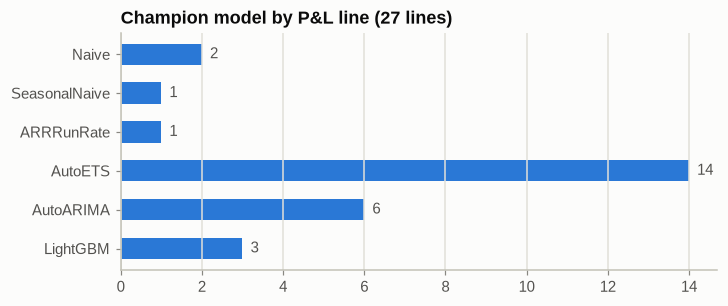

In [2]:
order = ["Naive", "SeasonalNaive", "ARRRunRate", "AutoETS", "AutoARIMA", "LightGBM"]
champs = read("champions")
mix = champs["champion"].value_counts().reindex(order).dropna().astype(int)
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(mix.index[::-1], mix.values[::-1], height=0.55, color=viz.SERIES[0])
for y, v in enumerate(mix.values[::-1]):
    ax.text(v + 0.2, y, str(v), va="center", color=viz.INK_2)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Champion model by P&L line (27 lines)")
plt.show()

Rent goes to **Naive** (nothing beats "same as last month" for a fixed lease), subscription revenue to the **ARR driver**, and LightGBM wins some payroll and commission lines, where the headcount plan helps.

## 2. Is it better than the budget?

In [3]:
s = read("accuracy_summary").iloc[0]
acc = read("accuracy_by_series")
wins = acc["rolling_forecast_wape"] < acc["budget_wape"]
print(f"Last 12 closed months ({s['window_start']} to {s['window_end']}), error (WAPE):")
print(f"  Rolling forecast, 1-12 months ahead: {s['rolling_forecast_wape']:.1%}")
print(f"  Static budget:                       {s['budget_wape']:.1%}")
print(f"  -> the rolling forecast is {s['improvement_vs_budget']:.0%} more accurate, and beats the budget on "
      f"{wins.sum()} of {len(acc)} lines ({acc.loc[wins, 'actual_12m_usd'].sum() / acc['actual_12m_usd'].sum():.0%} of P&L dollars)")

Last 12 closed months (2025-10 to 2026-09), error (WAPE):
  Rolling forecast, 1-12 months ahead: 8.4%
  Static budget:                       10.1%
  -> the rolling forecast is 17% more accurate, and beats the budget on 15 of 27 lines (88% of P&L dollars)


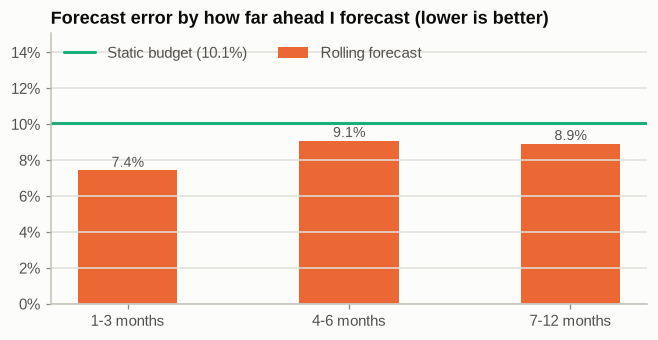

In [4]:
byh = read("accuracy_by_horizon")
fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(byh))
budget_wape = byh["budget_wape"].iloc[0]
ax.bar(x, byh["rolling_forecast_wape"], width=0.45, color=ROLE["forecast"], label="Rolling forecast")
ax.axhline(budget_wape, color=ROLE["budget"], linewidth=2, label=f"Static budget ({budget_wape:.1%})")
for xi, v in zip(x, byh["rolling_forecast_wape"]):
    ax.text(xi, v + 0.002, f"{v:.1%}", ha="center", color=viz.INK_2, fontsize=9)
ax.set_xticks(x, byh["bucket"]); pct_axis(ax); ax.set_ylim(0, budget_wape * 1.5)
ax.set_title("Forecast error by how far ahead I forecast (lower is better)")
ax.legend(loc="upper left", ncol=2)
plt.show()

The advantage is largest for the next quarter, where monthly decisions are made.

## 3. What does a forecast look like?

Each month-end produces a new forecast *vintage*: steady subscription revenue on the left, seasonal marketing on the right.

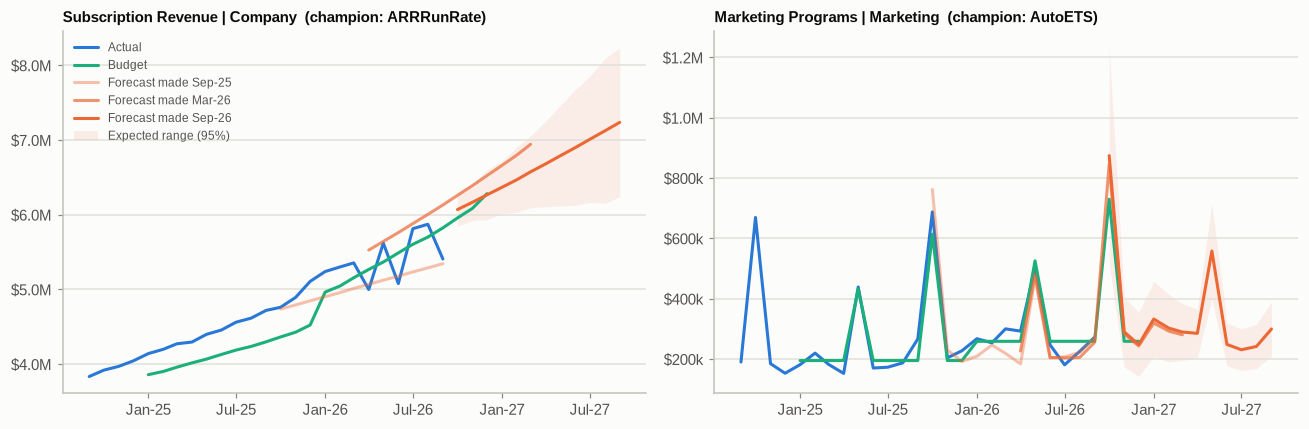

In [5]:
vint = read("forecast_vintages")
pnl = read("fct_monthly_pnl"); pnl["unique_id"] = pnl["fs_line"] + " | " + pnl["department"]
bud = read("fct_budget_monthly"); bud["unique_id"] = bud["fs_line"] + " | " + bud["department"]
for d in (pnl, bud):
    d["ds"] = pd.PeriodIndex(d["period"], freq="M").to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ["Subscription Revenue | Company", "Marketing Programs | Marketing"]):
    v = vint[(vint["unique_id"] == name) & vint["is_champion"]]
    a = pnl[(pnl["unique_id"] == name) & (pnl["ds"] >= "2024-09-01")]
    b = bud[(bud["unique_id"] == name) & (bud["ds"] >= "2025-01-01")]
    ax.plot(a["ds"], a["actual_usd"], color=ROLE["actual"], label="Actual")
    ax.plot(b["ds"], b["budget_usd"], color=ROLE["budget"], label="Budget")
    origins = sorted(v["origin"].unique())
    for alpha, o in zip((0.4, 0.7, 1.0), (origins[0], origins[len(origins) // 2], origins[-1])):
        f = v[v["origin"] == o]
        ax.plot(f["ds"], f["yhat"], color=ROLE["forecast"], alpha=alpha, label=f"Forecast made {pd.Timestamp(o):%b-%y}")
    live = v[v["origin"] == origins[-1]]
    ax.fill_between(live["ds"], live["lo95"], live["hi95"], color=ROLE["forecast"], alpha=0.10, linewidth=0, label="Expected range (95%)")
    usd_axis(ax); month_axis(ax)
    ax.set_title(f"{name}  (champion: {live['model'].iloc[0]})", fontsize=10)
axes[0].legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

The shaded band is the **expected range**, learned from the champion's own past errors. [Notebook 03](03_variance_analysis.ipynb) treats an actual outside it as a surprise.

## 4. Where is it weak?

Bias is the average % by which forecasts miss, by months ahead.

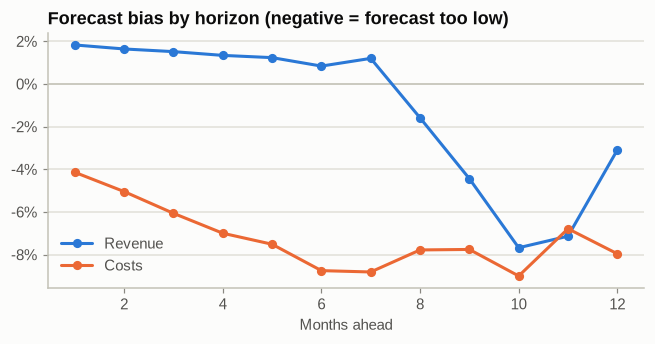

In [6]:
series_meta = read("series_meta")
v = vint[vint["is_champion"] & vint["y"].notna() & (vint["origin"] >= (AS_OF - 12).to_timestamp()) & (vint["origin"] < AS_OF.to_timestamp())]
v = v.merge(series_meta[["unique_id", "account_type"]], on="unique_id")
v["group"] = np.where(v["account_type"] == "Revenue", "Revenue", "Costs")
bias = v.groupby(["group", "horizon"]).apply(lambda g: (g["yhat"] - g["y"]).sum() / g["y"].sum(), include_groups=False).unstack(0)
fig, ax = plt.subplots(figsize=(7, 3))
ax.axhline(0, color=viz.AXIS, linewidth=1)
ax.plot(bias.index, bias["Revenue"], marker="o", markersize=5, color=viz.SERIES[0], label="Revenue")
ax.plot(bias.index, bias["Costs"], marker="o", markersize=5, color=viz.SERIES[1], label="Costs")
pct_axis(ax); ax.set_xlabel("Months ahead"); ax.legend()
ax.set_title("Forecast bias by horizon (negative = forecast too low)")
plt.show()

- **Revenue** runs low 9-12 months out: the mid-2025 price increase kept lifting ARR as contracts renewed.
- **Costs** run several percent low, partly from one-off spikes (what the flags are for) and partly from the 2026 hiring acceleration, which history-only models lag.

**Fix:** a driver-based personnel model (headcount plan × cost per head) and overlaying known pricing decisions.

## 5. Where will the year land?

Year-to-date actuals plus the forecast for the remaining months, against the full-year budget.

In [7]:
o = read("fy_outlook")
o["group"] = np.where(o["account_type"] == "Revenue", "Revenue", "Costs")
t = o.groupby("group")[["ytd_actual_usd", "remaining_forecast_usd", "fy_outlook_usd", "fy_budget_usd"]].sum()
t.loc["Operating income"] = t.loc["Revenue"] - t.loc["Costs"]
t["outlook_vs_budget"] = t["fy_outlook_usd"] - t["fy_budget_usd"]
print(f"FY{o['fiscal_year'].iloc[0]}: {o['months_actual'].iloc[0]} months actual + {12 - o['months_actual'].iloc[0]} months forecast")
t.style.format(lambda v: usd(v))

FY2026: 9 months actual + 3 months forecast


,ytd_actual_usd,remaining_forecast_usd,fy_outlook_usd,fy_budget_usd,outlook_vs_budget
group,,,,,
Costs,$59.4M,$20.6M,$80.0M,$81.9M,-$1.9M
Revenue,$53.2M,$19.9M,$73.1M,$72.8M,$346k
Operating income,-$6.2M,-$675k,-$6.9M,-$9.1M,$2.2M


**Next:** [notebook 03](03_variance_analysis.ipynb) turns the expected range into variance flags.